In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#Import the Dataset
# df= pd.read_csv("../dataset/official_Phishing_Email.csv")
# df.head()

In [4]:
#Import the Dataset
df = pd.read_csv('../dataset/Arabic_dataset.csv', delimiter=';',quoting=1)
df.replace(r'\n', ' ', regex=True, inplace=True)
df.head()

,ت,Email Text,Email Type
0,1,المساعدة التجارية العاجلة والشراكة. صديقي ال...,Phish Email - 1
1,2,صديقي العزيز، أنا السيد بن سليمان ضابط جمارك ...,Phish Email - 2
2,3,من جلالة الملك (HRM) حاكم تاج مملكة إليم الرئي...,Phish Email - 3
3,4,يوم جيد عزيزي أعلم أن هذا البريد سيأتي إليك ك...,Phish Email - 4
4,5,من MR. جودوين أكويزي هاتف: +233 208216645 فاكس...,Phish Email - 5


In [5]:
# Check NAN values
df.isna().sum()

ت             0
Email Text    0
Email Type    0
dtype: int64

In [6]:
#Drop tha Na values
# df = df.dropna()
# print(df.isna().sum())

In [7]:
#dataset shape
df.shape

(1250, 3)

In [8]:
# # Count the occurrences of each E-mail type. 
# email_type_counts = df['Email Type'].value_counts()
# print(email_type_counts)

In [9]:
# Extract the first two words
df['Filtered Email Type'] = df['Email Type'].str.extract(r'^(\w+\s\w+)')
df = df.drop(columns=['Email Type'])

In [10]:
# Count occurrences of each unique label
email_type_counts = df['Filtered Email Type'].value_counts()
print(email_type_counts)

Filtered Email Type
Legal Email    1000
Phish Email     250
Name: count, dtype: int64


In [11]:
# # Create the bar chart
# # Create a list of unique email types
# unique_email_types = email_type_counts.index.tolist()

# # Define a custom color map 
# color_map = {
#     'Phishing Email': 'red',
#     'Safe Email': 'blue',}

# # Map the colors to each email type
# colors = [color_map.get(email_type, 'gray') for email_type in unique_email_types]

# # Create the bar chart with custom colors
# plt.figure(figsize=(8, 6))
# plt.bar(unique_email_types, email_type_counts, color=colors)
# plt.xlabel('Email Type')
# plt.ylabel('Count')
# plt.title('Distribution of Email Types with Custom Colors')
# plt.xticks(rotation=45)

# # Show the chart
# plt.tight_layout()
# plt.show()

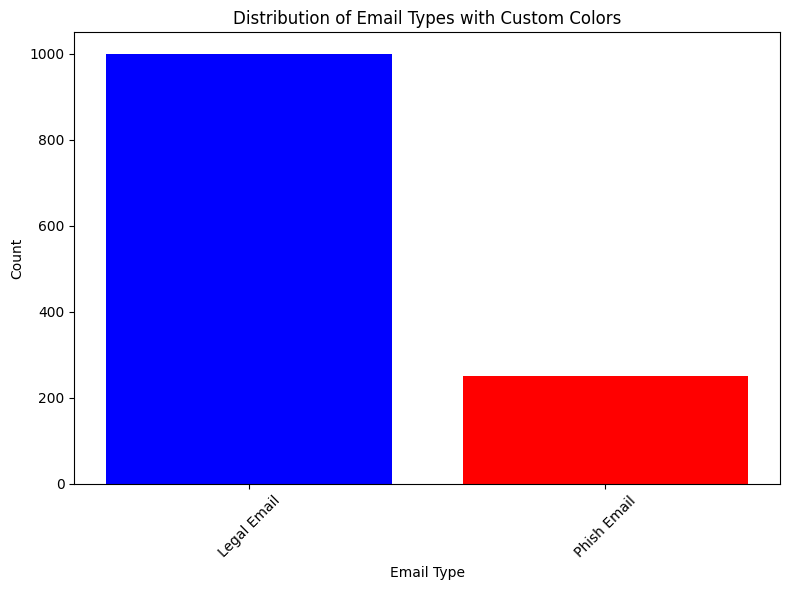

In [12]:
# Create the bar chart
# Create a list of unique email types
unique_email_types = email_type_counts.index.tolist()

# Define a custom color map 
color_map = {
    'Phish Email': 'red',
    'Legal Email': 'blue',}

# Map the colors to each email type
colors = [color_map.get(email_type, 'gray') for email_type in unique_email_types]

# Create the bar chart with custom colors
plt.figure(figsize=(8, 6))
plt.bar(unique_email_types, email_type_counts, color=colors)
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.title('Distribution of Email Types with Custom Colors')
plt.xticks(rotation=45)

# Show the chart
plt.tight_layout()
plt.show()

In [13]:
# # We will use undersapling technique 
# Safe_Email = df[df["Email Type"]== "Safe Email"]
# Phishing_Email = df[df["Email Type"]== "Phishing Email"]
# Safe_Email = Safe_Email.sample(Phishing_Email.shape[0])

In [14]:
# We will use undersapling technique 
Safe_Email = df[df["Filtered Email Type"]== "Legal Email"]
Phishing_Email = df[df["Filtered Email Type"]== "Phish Email"]
Safe_Email = Safe_Email.sample(Phishing_Email.shape[0])

In [15]:
# lets check the sahpe again 
Safe_Email.shape,Phishing_Email.shape

((250, 3), (250, 3))

In [16]:
# lest create a new Data with the balanced E-mail types
Data= pd.concat([Safe_Email, Phishing_Email], ignore_index = True)
Data.head()

,ت,Email Text,Filtered Email Type
0,509,لا بأس ، إيما تحصل على مشروب أو شيء ما. تريدني...,Legal Email
1,900,لا ، ستصاب بالصداع وأنت تحاول اكتشافه. يمكنك ا...,Legal Email
2,478,سأتصل بـ u 2mrw في نينيش ، مع عنواني الذي لن ي...,Legal Email
3,301,نعم. أنا رجل وسأعاملك بكرامة واحترام.,Legal Email
4,797,مهلا ، يمكنك الدفع. براتب دي. فقط & lt ؛ # & G...,Legal Email


In [17]:
# # split the data into a metrix of features X and Dependent Variable y
# X = Data["Email Text"].values
# y = Data["Email Type"].values

In [18]:
# split the data into a metrix of features X and Dependent Variable y
X = Data["Email Text"].values
y = Data["Filtered Email Type"].values

In [19]:
# lets splitting Our Data 
from sklearn.model_selection import train_test_split
X_train,x_test,y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [20]:
# Importing Libraries for the model ,Tfidf and Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

# define the Classifier
classifier = Pipeline([("tfidf",TfidfVectorizer()),("classifier",RandomForestClassifier(class_weight='balanced',n_estimators=10))])# add another hyperparamters as U want

In [21]:
# Trian Our model
classifier.fit(X_train,y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=10))])

In [22]:
# Prediction
y_pred = classifier.predict(x_test)

In [23]:
# Importing classification_report,accuracy_score,confusion_matrix
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,recall_score,precision_score

In [24]:
#accuracy_score
accuracy = accuracy_score(y_test,y_pred)

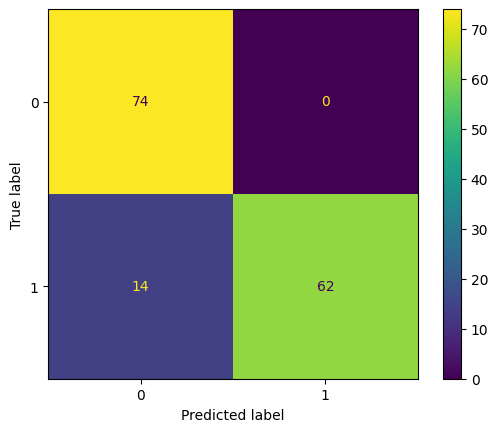

In [25]:
#confusion_matrix
conf = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(confusion_matrix=conf).plot()

In [27]:
precision = precision_score(y_test, y_pred,pos_label="Phish Email")
recall = recall_score(y_test, y_pred,pos_label="Phish Email")

In [29]:
# record accuracy in file
with open("arabic_rf_model_accuracy.txt", "a") as file:
    file.write(f"\n  Model Accuracy: {accuracy:.2f}\n Recall:{recall:.2f}\n Precision:{precision:.2f} \n Confusion matrix: \n{conf}")